In [1]:
from utils.paths import DATABASE_DIR,RAW_DIR,PREDICTIONS_DIR
from models_scripts.gp_workflow import ExperimentalGPApproach

from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength
from data.splitting import DataSplitter
from data.preprocessing import prepare_train_test
from data.Descriptors import AlloyDescriptorCalculator
from evaluation.evaluation import compute_permutation_importance, importance_to_df

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

In [2]:
from utils.paths import DATABASE_DIR,RAW_DIR,PREDICTIONS_DIR
from models_scripts.gp_workflow import ExperimentalGPApproach

from data.data_loading import load_table
from data.processing import merge_data, filter_by_wavelength
from data.splitting import DataSplitter
from data.preprocessing import prepare_train_test
from data.Descriptors import AlloyDescriptorCalculator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ternary

Load data
1. Experimental data (1552)
2. Resistivity calculation using ANN

In [16]:
df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")
# --- Merge ---
df_merged = merge_data(df_optical, df_comp) # Delete the pure elements
#df_merged = df_merged[~df_merged["ID"].isin([29, 30, 31])]
# --- Filter ---
tern_1550 = filter_by_wavelength(df_merged, 1550)
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[['ID','resistivity']])
# All space
comp_space = pd.read_csv(RAW_DIR/"CuNiAl_descriptors.csv")

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


splitting method selection based on the composition
1. Radom splitting
2. CLuster-based splitting

In [17]:
X = tern_1550[['Cu','Ni','Al','resistivity']].copy()
y = tern_1550['e2'].copy()

splitter = DataSplitter(
    test_size=0.20,
    random_state=42,
    split_method="cluster",
    n_clusters=8
)

split_dict = splitter.split(X, y)

In [5]:
df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")

# --- Merge full data ---
df_merged = merge_data(df_optical, df_comp)

# -------------------------------
# 1) Extract pure compositions
# -------------------------------
pure_ids = [29, 30, 31]

df_pure = df_merged[df_merged["ID"].isin(pure_ids)].copy()
df_no_pure = df_merged[~df_merged["ID"].isin(pure_ids)].copy()

# -------------------------------
# 2) Extract e2 at wavelength 234
# -------------------------------
df_e2_234 = filter_by_wavelength(df_no_pure, 234).copy()
df_e2_234 = df_e2_234[["ID", "e2"]].rename(columns={"e2": "e2_234"})

# --- Main dataframe for splitting ---
tern_1550 = filter_by_wavelength(df_no_pure, 1550).copy()
tern_1550 = tern_1550.reset_index(drop=True)

# add resistivity
tern_1550 = merge_data(tern_1550, df_resis_ANN[["ID", "resistivity"]])

# add e2_234
tern_1550 = merge_data(tern_1550, df_e2_234)

# -------------------------------
# Prepare X and y
# -------------------------------
X = tern_1550[["Cu", "Ni", "Al", "resistivity", "e2_234"]].copy()
y = tern_1550["e2"].copy()

splitter = DataSplitter(
    test_size=0.20,
    random_state=42,
    split_method="cluster",
    n_clusters=7
)

split_dict = splitter.split(X, y)

# -------------------------------
# Add pure metals back to training
# -------------------------------
# prepare pure rows at 1552 nm
pure_1550 = filter_by_wavelength(df_pure, 1550).copy()
pure_1550 = merge_data(pure_1550, df_resis_ANN[["ID", "resistivity"]])

# add e2_234 for pure rows
pure_e2_234 = filter_by_wavelength(df_pure, 234).copy()
pure_e2_234 = pure_e2_234[["ID", "e2"]].rename(columns={"e2": "e2_234"})
pure_1550 = merge_data(pure_1550, pure_e2_234)

X_pure = pure_1550[["Cu", "Ni", "Al", "resistivity", "e2_234"]].copy()
y_pure = pure_1550["e2"].copy()

# concatenate to training only
split_dict["X_train"] = pd.concat([split_dict["X_train"], X_pure], ignore_index=True)
split_dict["y_train"] = pd.concat([split_dict["y_train"], y_pure], ignore_index=True)

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


In [13]:
import pandas as pd

df_optical = load_table(DATABASE_DIR / "Ternary_round1.db", "Optical_properties")
df_comp = load_table(DATABASE_DIR / "Ternary_round1.db", "compositions")
df_resis_ANN = load_table(DATABASE_DIR / "Ternary_round1.db", "ANN_resistivity")

# --- Merge full data ---
df_merged = merge_data(df_optical, df_comp)

# -------------------------------
# Extract pure compositions
# -------------------------------
pure_ids = [29, 30, 31]

df_pure = df_merged[df_merged["ID"].isin(pure_ids)].copy()
df_no_pure = df_merged[~df_merged["ID"].isin(pure_ids)].copy()

# -------------------------------
# Main dataframe for splitting
# -------------------------------
tern_1550 = filter_by_wavelength(df_no_pure, 1550).copy()
tern_1550 = tern_1550.reset_index(drop=True)
tern_1550 = merge_data(tern_1550, df_resis_ANN[["ID", "resistivity"]])

X = tern_1550[["Cu", "Ni", "Al", "resistivity"]].copy()
y = tern_1550["e2"].copy()

splitter = DataSplitter(
    test_size=0.20,
    random_state=42,
    split_method="cluster",
    n_clusters=8
)

split_dict = splitter.split(X, y)

# -------------------------------
# Add pure metals back to training
# -------------------------------
pure_1550 = filter_by_wavelength(df_pure, 1552.0).copy()
pure_1550 = merge_data(pure_1550, df_resis_ANN[["ID", "resistivity"]])

X_pure = pure_1550[["Cu", "Ni", "Al", "resistivity"]].copy()
y_pure = pure_1550["e2"].copy()

split_dict["X_train"] = pd.concat([split_dict["X_train"], X_pure], ignore_index=True)
split_dict["y_train"] = pd.concat([split_dict["y_train"], y_pure], ignore_index=True)

Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed
Connected to database: /Users/linarojas/Desktop/Research/Papers/Combinatorial_Ternary/Hybrid-Experimental-Data-Driven-Workflow/data/databases/Ternary_round1.db
Database connection closed


/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/ternary/plotting.py:148: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  ax.scatter(xs, ys, vmin=vmin, vmax=vmax, **kwargs)


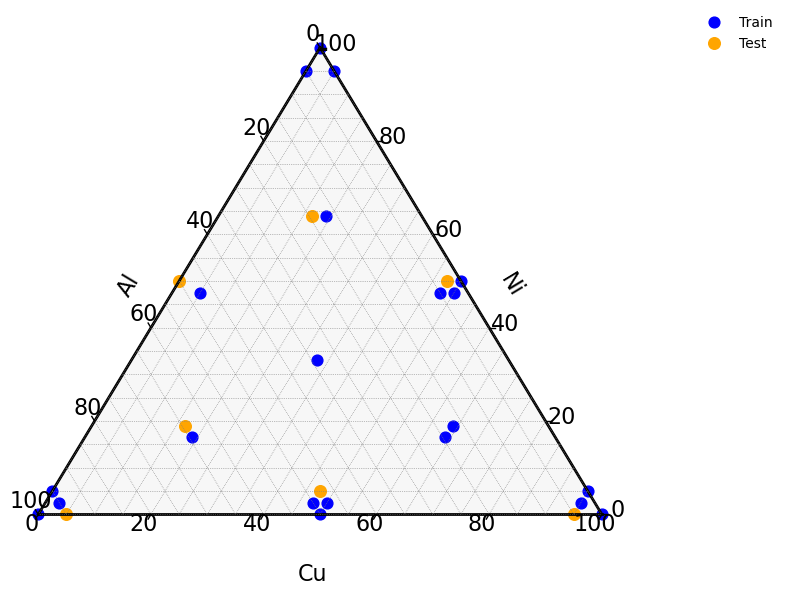

In [14]:
train_comp_cluster = np.asarray(split_dict['X_train'][['Cu','Ni','Al']], dtype=float)*100
test_comp_cluster = np.asarray(split_dict['X_test'][['Cu','Ni','Al']], dtype=float)*100

scale = 100
fig, tax = ternary.figure(scale=scale)
fig.set_size_inches(8, 7)

def to_ternary_points(arr_pct, scale=100):

    pts = (arr_pct / 100.0 * scale)
    return [tuple(p) for p in pts]

pts_A = to_ternary_points(train_comp_cluster, scale)
pts_B = to_ternary_points(test_comp_cluster, scale)

tax.scatter(pts_A, marker="o", s=60, color="blue", label="Train")
tax.scatter(pts_B, marker="o", s=70, color="orange", label="Test")


tax.boundary(linewidth=2)
tax.gridlines(color="gray", multiple=5)
tax.ticks(axis="lbr", multiple=20, linewidth=1, fontsize=16)

tax.left_axis_label("Al",fontsize=16,offset=0.1)
tax.right_axis_label("Ni",fontsize=16,offset=0.1)
tax.bottom_axis_label("Cu",fontsize=16,offset=0.05)

tax.clear_matplotlib_ticks()
tax.get_axes().axis("off")
tax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05), frameon=False)

Load the descriptors

In [5]:
calc = AlloyDescriptorCalculator()
descriptor_spec = {
    "atomic_radius": ["avg","mismatch"],
    "metallic_radius": ["avg","mismatch"],
    "electronegativity_pauling": ["avg","mismatch"],
    "electronegativity_allen": ["avg","mismatch"],
    "valence_electrons": ["avg","mismatch"],
    "density": ["avg","mismatch"],
    "electron_affinity": ["avg","mismatch"],
    "ionization_energy_1": ["avg","mismatch"],
    "ionization_energy_2": ["avg","mismatch"],
    "valence_s": ["avg","mismatch"],
    "valence_d": ["avg","mismatch"]
}

x_train = calc.transform(split_dict['X_train'], descriptor_spec=descriptor_spec, include_entropy=True)
x_test = calc.transform(split_dict['X_test'], descriptor_spec=descriptor_spec, include_entropy=True)

In [6]:
y_train = split_dict['y_train']
y_test = split_dict['y_test']

In [18]:
# Property calculator
calc = AlloyDescriptorCalculator()
descriptor_spec = {
    "metallic_radius": ["avg","mismatch"],
    "valence_electrons": ["avg"],
    "density": ["avg"],
    "ionization_energy_2": ["avg","mismatch"],
    "valence_s": ["mismatch"],
    "valence_d": ["mismatch"]
}

x_train = calc.transform(split_dict['X_train'], descriptor_spec=descriptor_spec, include_entropy=True)
x_test = calc.transform(split_dict['X_test'], descriptor_spec=descriptor_spec, include_entropy=True)

# Optical properties
y_train = split_dict['y_train']
y_test = split_dict['y_test']


In [21]:
x_train = x_train.drop(columns=['Cu','Ni','Al','resistivity'])
x_test = x_test.drop(columns=['Cu','Ni','Al','resistivity'])

In [17]:
x_train.to_csv("x_train.csv", index=False)
x_test.to_csv("x_test.csv", index=False)
y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

In [9]:
import pickle

gpy_dic = {
    "X_train": x_train,
    "X_test": x_test,
    "y_train": y_train,
    "y_test": y_test
}

with open("gpy_dic.pkl", "wb") as f:
    pickle.dump(gpy_dic, f)


Gaussian Process mean  = 0

In [22]:
gp_exp = ExperimentalGPApproach(
    random_state=42,
    n_splits=5,
    scoring="r2",
    n_restarts_optimizer=5,
)

results = gp_exp.fit_and_evaluate(
    X_train=x_train,
    y_train=y_train,
    X_test=x_test,
    y_test=y_test,
)

model = gp_exp.model_

print("Best CV score:", results["best_score_cv"])
print("Best params:")
print(results["best_params"])
print("Train metrics:", results["train_metrics"])
print("Test metrics:", results["test_metrics"])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scale

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Use

[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.2s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=1e-08, gp__kernel=1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1e-

...

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Use

[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1e-05), scaler=passthrough; total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKer

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/

[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.1s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=StandardScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END gp__alpha=0.0001, gp__kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1e-05), scaler=MinMaxScaler(); total time=   0.2s
[CV] END

/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 40 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/linarojas/opt/anaconda3/envs/hybrid/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


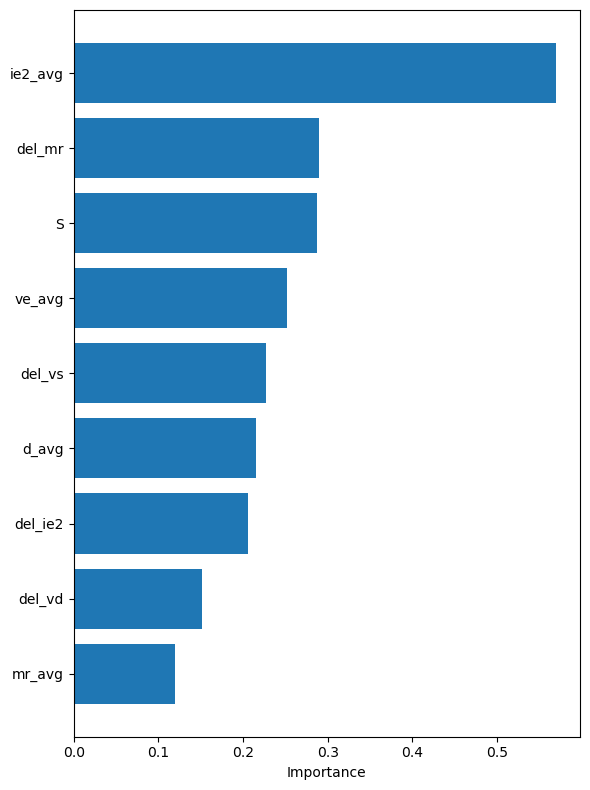

In [23]:
feature_names = x_test.columns

imp = compute_permutation_importance(model, x_test, y_test)
df_imp = importance_to_df(imp, feature_names)


plt.figure(figsize=(6,8))
plt.barh(df_imp["feature"], df_imp["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [18]:
df_wave = pd.read_csv(PREDICTIONS_DIR/"GP-Experiments/GP_wavelength_r2.csv")

In [19]:
df_wave.tail(5)

,wavelength,r2
1036,1294,-0.183749
1037,1270,-0.183931
1038,1288,-0.184094
1039,1276,-0.184236
1040,1282,-0.184256


In [20]:
df_wave.loc[df_wave['r2'].idxmax()]

wavelength    234.000000
r2              0.947703
Name: 0, dtype: float64

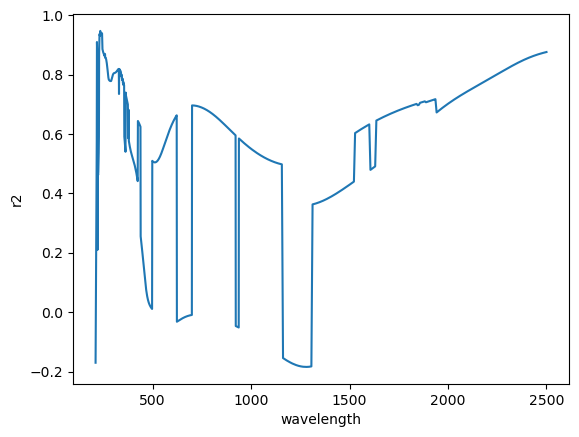

In [21]:
import matplotlib.pyplot as plt

df_wave = df_wave.sort_values('wavelength')
plt.plot(df_wave['wavelength'], df_wave['r2'])
plt.xlabel('wavelength')
plt.ylabel('r2')
plt.show()

In [1]:
import pickle

with open("gpy_dic.pkl", "rb") as f:
    data = pickle.load(f)

x_train = data["X_train"]
x_test  = data["X_test"]
y_train = data["y_train"]
y_test  = data["y_test"]

In [2]:
from models_scripts.gp_GPy import GPyMeanModel

model = GPyMeanModel()

model.fit(x_train, y_train)

metrics = model.evaluate(x_test, y_test)
print(metrics)

y_pred, y_std = model.predict(x_test)

reconstraining parameters gp.Gaussian_noise.variance


Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s00  0001   2.001868e+02   6.200648e+04 
    00s01  0008   1.451722e+01   2.286450e+02 
    00s04  0019  -3.730963e-02   4.848657e+01 
    00s10  0040  -4.611415e+00   5.381341e+01 
    00s19  0085  -6.034978e+00   7.317624e+00 
    00s88  1002  -9.206162e+00   9.323166e+00 
Runtime:     00s88
Optimization status: Maximum number of f evaluations reached

{'r2': 0.8428388275764789, 'rmse': 0.7569051892119397, 'mse': 0.5729054654559623}


Changing mean function

In [2]:
import numpy as np
import GPy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# --------------------------------------------------
# Assume you already have:
# X_train, X_test, y_train, y_test
# --------------------------------------------------

# Make sure shapes are correct
X_train = np.asarray(x_train, dtype=float)
X_test  = np.asarray(x_test, dtype=float)

y_train = np.asarray(y_train, dtype=float).reshape(-1, 1)
y_test  = np.asarray(y_test, dtype=float).reshape(-1, 1)

# -----------------------------
# Scale X
# -----------------------------
x_scaler = StandardScaler()
X_train_s = x_scaler.fit_transform(X_train)
X_test_s  = x_scaler.transform(X_test)

# -----------------------------
# Scale y
# -----------------------------
y_mean = y_train.mean()
y_std = y_train.std()
if y_std == 0:
    y_std = 1.0

y_train_s = (y_train - y_mean) / y_std

# -----------------------------
# Mean function: linear trend
# m(x) = A x
# -----------------------------
mean_func = GPy.mappings.Linear(
    input_dim=X_train.shape[1],
    output_dim=1
)

# -----------------------------
# Kernel: correlated residual
# -----------------------------
kernel = GPy.kern.Matern52(
    input_dim=X_train.shape[1],
    ARD=True
)

# -----------------------------
# Likelihood
# -----------------------------
likelihood = GPy.likelihoods.Gaussian()

# -----------------------------
# Build model
# -----------------------------
model = GPy.core.GP(
    X=X_train_s,
    Y=y_train_s,
    kernel=kernel,
    likelihood=likelihood,
    mean_function=mean_func
)

# Optional initial values
model.likelihood.variance = 1e-3
model.likelihood.variance.constrain_bounded(1e-8, 1.0)

# -----------------------------
# Optimize
# -----------------------------
model.optimize(optimizer="bfgs", max_iters=1000, messages=True)

# -----------------------------
# Predict
# -----------------------------
y_pred_s, y_var_s = model.predict(X_test_s)

# Back-transform
y_pred = y_pred_s * y_std + y_mean
y_std_pred = np.sqrt(y_var_s) * y_std

# -----------------------------
# Metrics
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(model)
print("Test R2 :", r2)
print("Test RMSE:", rmse)

reconstraining parameters gp.Gaussian_noise.variance


Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s00  0001   3.938194e+02   1.752064e+05 
    00s02  0009   1.942788e+01   7.299124e+01 
    00s03  0017   1.407315e+01   1.254982e+02 
    00s10  0026   1.020138e+01   3.607227e+01 
    00s13  0036  -7.293763e-02   2.237720e+03 
    00s14  0042  -1.764496e+00   1.513870e+01 
    00s16  0050  -3.406502e+00   8.889228e+02 
    00s19  0064  -3.617019e+00   2.378679e+03 
    00s89  1002  -8.032845e+00   2.068440e-02 
Runtime:     00s89
Optimization status: Maximum number of f evaluations reached


Name : gp
Objective : -8.032844730891266
Number of Parameters : 52
Number of Optimization Parameters : 52
Updates : True
Parameters:
  gp.                      |                   value  |  constraints  |  priors
  linmap.A                 |                 (25, 1)  |               |        
  Mat52.variance           |    0.026020830489877335  |      +ve      |        
  Mat52.lengthscale        |  